In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

In [2]:
explore = False

In [3]:
XXSMALL_SIZE = 8
XSMALL_SIZE = 10
SMALL_SIZE = 18
MEDIUM_SIZE = 20
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

## Explore false negatives

In [4]:
def read_stellar_output(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.drop([1, 2, 7], axis = 1, inplace = True) 
    df.columns = ["dname", "dbegin", "dend", "percid", "strand", "attr"]
    df["len"] = np.abs(df["dend"] - df["dbegin"])

    if (len(df['attr'].iloc[0].split(';')) == 5):
        df[['qname','seq2Range', 'evalue', 'cigar', 'mutations']] = df['attr'].str.split(';',expand=True)
    else:
        df[['qname','seq2Range', 'cigar', 'mutations']] = df['attr'].str.split(';',expand=True)
    
    df[["qbegin", "qend"]] = df["seq2Range"].str.removeprefix("seq2Range=").str.split(',',expand=True)
    
    df.drop(["cigar", "mutations", "attr", "seq2Range"], axis = 1, inplace = True)
    for col in ["dbegin", "dend", "qbegin", "qend"]:
        df[col] = pd.to_numeric(df[col])
    return df

def read_blast_output(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["dname", "dbegin", "dend", "percid", "strand", "evalue", "qname", "qbegin", "qend"]  
    df["len"] = np.abs(df["dend"] - df["dbegin"])
    return df
    
def switch_reverse_coord(variants):
    plus = variants[variants["strand"] == "+"].copy()
    minus = variants[variants["strand"] == "-"].copy()
    if (len(plus) == 0):
        plus = variants[variants["strand"] == "plus"].copy()
        minus = variants[variants["strand"] == "minus"].copy()
        
    minus["tmp"] = minus["dbegin"].copy()
    minus["dbegin"] = minus["dend"].copy()
    minus["dend"] = minus["tmp"]
    minus.drop(["tmp"], inplace = True, axis = 1)
    variants = pd.concat([plus, minus])
    for col in ["dbegin", "dend", "qbegin", "qend"]:
        variants[col] = pd.to_numeric(variants[col])
    return variants

def fit_line_coord(variants):
    variants = variants.assign(a = lambda x: ((x["qend"] - x["qbegin"]) / (x["dend"] - x["dbegin"])))
    variants = variants.assign(b = lambda x: (x["qbegin"] - x["a"] * x["dbegin"]))

    return variants

## Genomic features

In [5]:
# cd /srv/data/evelina/mouse
# grep ">" dna4.fasta | sed 's/>//g' | sed 's/,//g' | awk '{print "\"" $1 "\"" ":\t\"" $6 " " $7 "\","}' | grep -v Concatenated | sed 's/unplaced genomic/unplaced scaffold/g'
mouse_dname_d = {"NC_000067.7":	"1",
"NT_166280.1":	"1",
"NT_166281.1":	"1",
"NT_166282.1":	"1",
"NT_162750.1":	"1",
"NT_166338.1":	"1",
"NC_000068.8":	"2",
"NC_000069.7":	"3",
"NC_000070.7":	"4",
"NC_000071.7":	"5",
"NT_187056.1":	"5",
"NT_187057.1":	"5",
"NT_187058.1":	"5",
"NT_166438.1":	"5",
"NT_187059.1":	"5",
"NC_000072.7":	"6",
"NC_000073.7":	"7",
"NT_166307.1":	"7",
"NC_000074.7":	"8",
"NC_000075.7":	"9",
"NC_000076.7":	"10",
"NC_000077.7":	"11",
"NC_000078.7":	"12",
"NC_000079.7":	"13",
"NC_000080.7":	"14",
"NC_000081.7":	"15",
"NC_000082.7":	"16",
"NC_000083.7":	"17",
"NC_000084.7":	"18",
"NC_000085.7":	"19",
"NC_000086.8":	"X",
"NT_165789.3":	"X",
"NC_000087.8":	"Y",
"NT_187060.1":	"Y",
"NT_187061.1":	"Y",
"NT_187062.1":	"Y",
"NT_187063.1":	"Y",
"NT_166451.1":	"unplaced scaffold",
"NT_166462.1":	"unplaced scaffold",
"NT_166465.1":	"unplaced scaffold",
"NT_166466.1":	"unplaced scaffold",
"NT_166467.1":	"unplaced scaffold",
"NT_166469.1":	"unplaced scaffold",
"NT_166474.1":	"unplaced scaffold",
"NT_166476.1":	"unplaced scaffold",
"NT_166478.1":	"unplaced scaffold",
"NT_166443.1":	"unplaced scaffold",
"NT_166444.1":	"unplaced scaffold",
"NT_166480.1":	"unplaced scaffold",
"NT_166456.1":	"unplaced scaffold",
"NT_166471.1":	"unplaced scaffold",
"NT_166473.1":	"unplaced scaffold",
"NT_166454.1":	"unplaced scaffold",
"NT_166463.1":	"unplaced scaffold",
"NT_166450.1":	"unplaced scaffold",
"NT_166452.1":	"unplaced scaffold",
"NT_187064.1":	"unplaced scaffold",
"NW_023337853.1":	"unplaced scaffold",}

mouse_dname_d.get("NT_166473.1")

'unplaced scaffold'

In [6]:
fly_qname_d = {
    "NC_004354.4": "X",
    "NT_033779.5": "2L",
    "NT_033778.4": "2R",
    "NT_037436.4": "3L",
    "NT_033777.3": "3R",
    "NC_004353.4": "4",
    "NC_024512.1": "Y",
    "NW_007931110.1": "Y",
    "NW_007931119.1": "Y",
    "NW_007931108.1": "Y",
    "NW_007931109.1": "Y",
    "NW_007931074.1": "2CEN",
    "NW_007931076.1": "3CEN",
    "NW_007931078.1": "3CEN",
    "NW_007931086.1": "Unmapped_Scaffold_17_D1756_D1775",
    "NW_007931087.1": "Unmapped_Scaffold_22_D1753",
    "NW_007931089.1": "Unmapped_Scaffold_28_D1723",
    "NW_007931092.1": "Unmapped_Scaffold_35_D1599",
    "NW_007931082.1": "Unmapped_Scaffold_4_D1555_D1692",
    "NW_007931100.1": "Unmapped_Scaffold_52_D1739",
    "NW_007931083.1": "Unmapped_Scaffold_8_D1580_D1567",
    "NW_007931107.1": "X;",
    "NW_001844851.1": "X;",
    "NW_007931121.1": "X;",
    "NC_024511.2": "mitochondrion,",}

## Alignment files

In [7]:
dream_all = read_stellar_output("b4096_fpr0.005_l50_cmin0_cmax50_e3_s1111101001010011011111_ent1.0_cap1000_carts1024_t32.gff")
dream_all = switch_reverse_coord(dream_all)
dream_all = fit_line_coord(dream_all)
dream_all = dream_all[dream_all["dname"] != "Concatenated"]
dream_all.head()

,dname,dbegin,dend,percid,strand,len,qname,evalue,qbegin,qend,a,b
43,NC_000086.8,161350176,161350230,94.5454,+,54,NT_033779.5,eValue=7.91952e-10,4228348,4228402,1.000000,-1.571218e+08
44,NC_000086.8,161350108,161350163,94.6428,+,55,NT_033779.5,eValue=2.20192e-10,4228280,4228335,1.000000,-1.571218e+08
45,NC_000086.8,161349997,161350050,94.4444,+,53,NT_033779.5,eValue=2.84837e-09,4228169,4228222,1.000000,-1.571218e+08
46,NC_000086.8,161349853,161349905,94.4444,+,52,NT_033779.5,eValue=2.84837e-09,10409731,10409783,1.000000,-1.509401e+08
47,NC_000086.8,160852452,160852560,94.4954,+,108,NT_033777.3,eValue=1.0429e-34,24556087,24556194,0.990741,-1.348070e+08


In [8]:
blast_all = read_blast_output("mouse_vs_fly_e10_k28.bed")
blast_all = fit_line_coord(blast_all)
blast_all = blast_all[blast_all["dname"] != "Concatenated"]
blast_all.head()

,dname,dbegin,dend,percid,strand,evalue,qname,qbegin,qend,len,a,b
0,NC_000071.7,125463274,125464869,82.834,plus,0.0,NC_004354.4,6277153,6278748,1595,1.0,-119186121.0
1,NC_000071.7,125463731,125465325,82.761,plus,0.0,NC_004354.4,6277154,6278748,1594,1.0,-119186577.0
2,NC_000071.7,125463218,125464185,83.419,plus,0.0,NC_004354.4,6277781,6278748,967,1.0,-119185437.0
3,NC_000071.7,125463298,125464217,79.805,plus,0.0,NC_004354.4,6282296,6283215,919,1.0,-119181002.0
4,NC_000071.7,125464210,125465129,79.826,plus,0.0,NC_004354.4,6282296,6283215,919,1.0,-119181914.0


In [9]:
last_all = read_blast_output("mouse_vs_fly_w1_k1_m10.bed")
last_all = fit_line_coord(last_all)
last_all = last_all[last_all["dname"] != "Concatenated"]
last_all.head()

,dname,dbegin,dend,percid,strand,evalue,qname,qbegin,qend,len,a,b
0,NC_005089.1,5343,6775,74.11,plus,0.000000e+00,NC_024511.2,1483,2915,1432,1.0,-3860.0
1,NC_000068.8,22479644,22478212,73.69,minus,0.000000e+00,NC_024511.2,1483,2915,1432,-1.0,22481127.0
2,NC_005089.1,14155,15200,67.40,plus,1.900000e-160,NC_024511.2,10512,11557,1045,1.0,-3643.0
3,NC_000070.7,79922236,79923281,66.73,plus,8.700000e-154,NC_024511.2,10512,11557,1045,1.0,-79911724.0
4,NC_000077.7,90429962,90429406,75.58,minus,7.600000e-123,NC_024511.2,2357,2913,556,-1.0,90432319.0


In [10]:
lastz_all = read_blast_output("mouse_vs_fly_s111101001100101011111_gapped_transition_3.bed")
lastz_all = switch_reverse_coord(lastz_all)
lastz_all = fit_line_coord(lastz_all)
lastz_all = lastz_all[lastz_all["dname"] != "Concatenated"]
lastz_all.head()

,dname,dbegin,dend,percid,strand,evalue,qname,qbegin,qend,len,a,b
0,NC_000067.7,4326444,4326594,64.42,plus,1.300000e-26,NC_004354.4,2025527,2025686,150,1.060000,-2.560504e+06
1,NC_000067.7,4329098,4330149,59.57,plus,2.400000e-138,NC_004354.4,2025847,2026912,1051,1.013321,-2.360917e+06
2,NC_000067.7,4330147,4330739,52.94,plus,7.300000e-74,NC_004354.4,2027284,2028035,592,1.268581,-3.465859e+06
3,NC_000067.7,6877789,6877875,72.41,plus,6.000000e-18,NC_004354.4,4085669,4085755,86,1.000000,-2.792120e+06
4,NC_000067.7,7206418,7206812,71.72,plus,1.200000e-101,NC_004354.4,13335984,13336379,394,1.002538,6.111276e+06


### Value counts across chr pairs

In [11]:
def make_count_table(df):
    d = {}
    all_qnames = np.unique(pd.concat([dream_all, blast_all, last_all, lastz_all]).qname)
    all_dnames = np.unique(pd.concat([dream_all, blast_all, last_all, lastz_all]).dname)
    for qname in all_qnames:
        query_list = []
        for dname in all_dnames:
            query_list.append(len(df[(df.dname == dname) & (df.qname == qname)]))
        qname = fly_qname_d.get(qname)
        d[qname] = query_list

    mouse_chr_names = pd.Series(all_dnames).apply(lambda x : "chr" + str(mouse_dname_d.get(x)))
    counts = pd.DataFrame(data = d, index = mouse_chr_names)
    counts.drop("chrNone", inplace = True)
    cols = ["2L", "2R", "3L", "3R", "X"]
    counts = counts[cols]
    return counts

In [16]:
corr_matrix = []
for this in [dream_all, blast_all, last_all, lastz_all]:
    this_counts = make_count_table(this).to_numpy().ravel()
    this_corr = []
    for other in [dream_all, blast_all, last_all, lastz_all]:  
        other_counts = make_count_table(other).to_numpy().ravel()
        this_corr.append(np.corrcoef(this_counts, other_counts)[0, 1])
    corr_matrix.append(this_corr)

corr_df = pd.DataFrame(data = corr_matrix)
corr_df.columns = ["DREAM", "BLAST", "LAST", "LASTZ"]
corr_df.index = ["DREAM", "BLAST", "LAST", "LASTZ"]
corr_df

,DREAM,BLAST,LAST,LASTZ
DREAM,1.000000,0.894293,0.594190,0.307983
BLAST,0.894293,1.000000,0.679295,0.320301
LAST,0.594190,0.679295,1.000000,0.506838
LASTZ,0.307983,0.320301,0.506838,1.000000


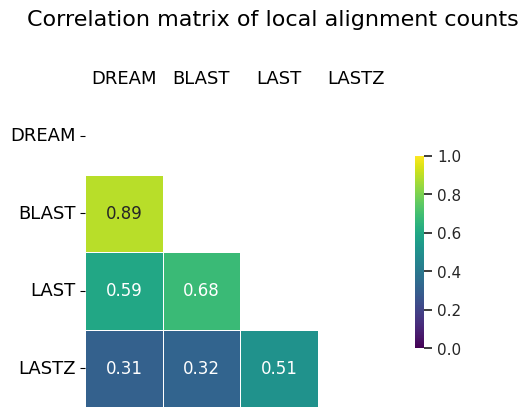

In [17]:
fig, axs = plt.subplots(figsize = (5, 5))
plt.suptitle("Correlation matrix of local alignment counts")

plt.yticks(rotation=90) 

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.set_theme(style = "white")

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_df, cmap = sns.color_palette("viridis", as_cmap = True), mask=mask, annot = True, square=True, vmin = 0, vmax = 1.0, linewidths=.5, cbar_kws={"shrink": .5})
plt.tick_params(axis='both', which='major', labelsize=13, labelbottom = False, bottom=False, top = False, labeltop=True)

fig.savefig("mouse_vs_fly.corr.svg", dpi=400, bbox_inches='tight')

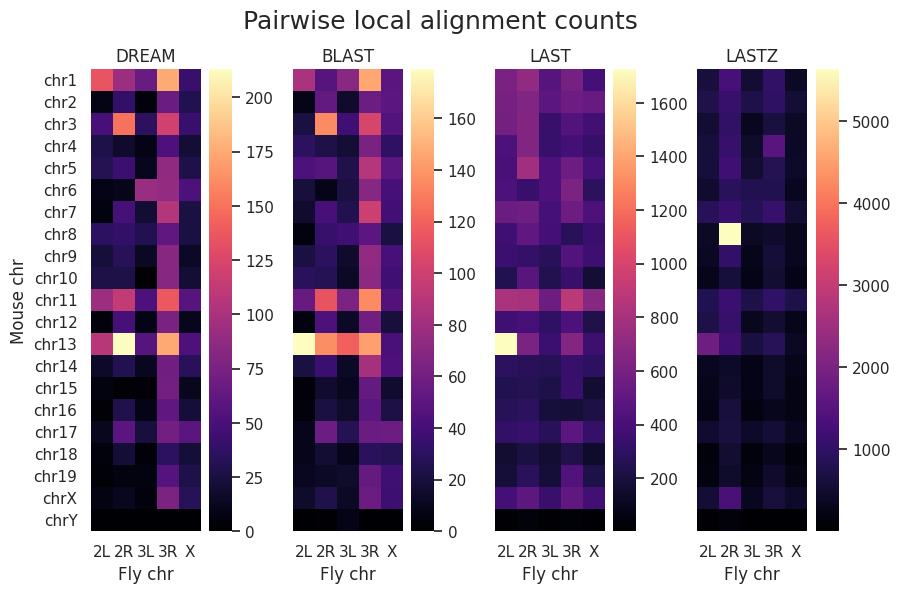

In [18]:
fig, axs = plt.subplots(1,4, sharey = True)
fig.suptitle('Pairwise local alignment counts', fontsize=BIGGER_SIZE)
fig.set_size_inches(10, 6)
#fig.suptitle('Query k-mer thresholds')

#for i in range(3):
#    axs[i].set_box_aspect(1)

count_min = 0
last_count_max = np.max(make_count_table(lastz_all))
dream_count_max = np.max(make_count_table(pd.concat([dream_all, blast_all])))

#sns.heatmap(make_count_table(dream_all), vmin=count_min, vmax=dream_count_max, ax = axs[0][0], square = True, cbar = False)
sns.heatmap(make_count_table(dream_all), cmap = sns.color_palette("magma", as_cmap = True), ax = axs[0], square = True)

axs[0].set_ylabel("Mouse chr")
axs[0].set_title("DREAM")

#sns.heatmap(make_count_table(blast_all), vmin=count_min, vmax=dream_count_max, ax = axs[0][1], square = True, cbar_ax = axs[0][2])    
sns.heatmap(make_count_table(blast_all), cmap = sns.color_palette("magma", as_cmap = True), ax = axs[1], square = True)    

axs[1].set_title("BLAST")

#sns.heatmap(make_count_table(last_all), vmin=count_min, vmax=last_count_max, ax = axs[1][0], square = True, cbar = False)
sns.heatmap(make_count_table(last_all), cmap = sns.color_palette("magma", as_cmap = True), ax = axs[2], square = True)
axs[2].set_title("LAST")

#sns.heatmap(make_count_table(lastz_all), vmin=count_min, vmax=last_count_max, ax = axs[1][1], square = True, cbar_ax = axs[1][2])    
sns.heatmap(make_count_table(lastz_all), cmap = sns.color_palette("magma", as_cmap = True), ax = axs[3], square = True)    
axs[3].set_title("LASTZ")

for i in range(4):
    axs[i].set_xlabel("Fly chr")
    
fig.savefig("mouse_vs_fly.counts.svg", dpi=400, bbox_inches='tight')
plt.show()

In [10]:
def plot_mouse_chr(dream, blast, last, lastz, full = True):
    fig, ax = plt.subplots(2, 2, sharey = True, sharex = True)

    i = 0
    for df in [dream, blast, last, lastz]:
        for index, row in df.iterrows():
            if (row["strand"] == "+") or (row["strand"] == "plus"):
                ax[i // 2][i % 2].plot(np.array(row[["dbegin", "dend"]]), np.array(row[["qbegin", "qend"]]), '-', color = CB_color_cycle[0], label = "+")
            else:
                ax[i // 2][i % 2].plot(np.array(row[["dbegin", "dend"]]), np.array(row[["qbegin", "qend"]]), '-', color = CB_color_cycle[7], label = "-")
        ax[i // 2][i % 2].set_aspect('equal', 'box')
        i += 1
        
    # LASTZ
    if (full): 
        fig.set_figwidth(15)
        fig.set_figheight(5)
    else:
        fig.set_figwidth(8)
        fig.set_figheight(8)
    
    ax[0][0].set_title('DREAM')
    ax[0][0].tick_params(labelbottom=True, labelleft=True, bottom = True, left = True)
    ax[0][1].set_title('BLAST')
    ax[0][1].tick_params(labelbottom=True, labelleft=True, bottom = True, left = True)
    ax[1][0].set_title('LAST')
    ax[1][0].tick_params(labelbottom=True, labelleft=True, bottom = True, left = True)
    ax[1][1].set_title('LASTZ')
    ax[1][1].tick_params(labelbottom=True, labelleft=True, bottom = True, left = True)
    
    #ax[2].legend(loc = "upper center")
    #fig.legend(handles, labels, loc='upper center')
    fig.subplots_adjust(bottom = 0.1, top = 0.87)
     
    mouse_chr = mouse_dname_d.get(dream["dname"].iloc[0])
    fly_chr = fly_qname_d.get(dream["qname"].iloc[0])
    
    ax[0][0].set_ylabel("Fly chr" + fly_chr)
    ax[1][0].set_ylabel("Fly chr" + fly_chr)

    ax[1][0].set_xlabel("Mouse chr" + mouse_chr)
    ax[1][1].set_xlabel("Mouse chr" + mouse_chr)

    #bottom, top = ax[1].get_ylim()
    #ax[0].set_ylim(bottom, top)
    
    #fig.suptitle("Human and mouse synteny")
    fig.savefig("mouse_" + mouse_chr + '_fly_' + fly_chr + '.svg', dpi = 200)
    fig.savefig("mouse_" + mouse_chr + '_fly_' + fly_chr + '.png', dpi = 200)

def get_df(df_all, dname, qname, dmin, dmax):
    df = df_all[(df_all.qname == qname) & (df_all.dname == dname)]
    df = df[(df["dbegin"] > dmin) & (df["dbegin"] < dmax)]
    return df

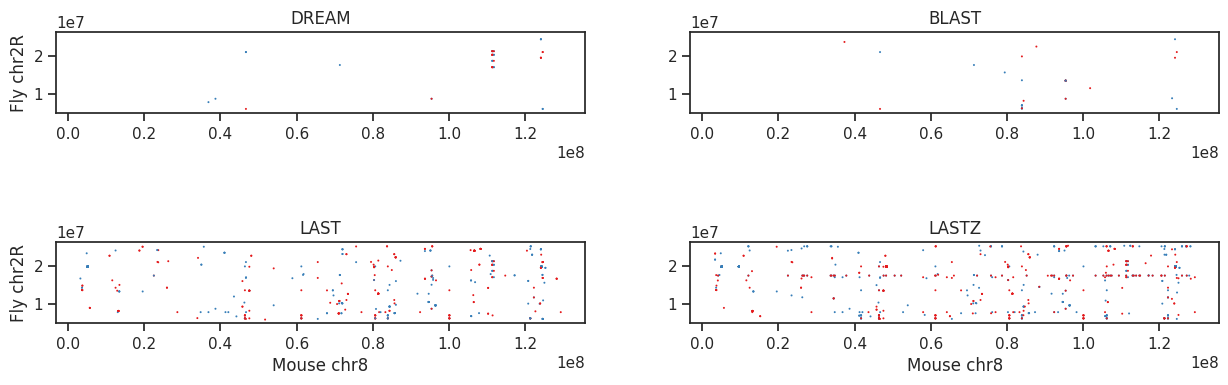

In [20]:
# LASTZ max
dname = "NC_000074.7"
qname = "NT_033778.4"
dream = dream_all[(dream_all.qname == qname) & (dream_all.dname == dname)]
blast = blast_all[(blast_all.qname == qname) & (blast_all.dname == dname)]
last = last_all[(last_all.qname == qname) & (last_all.dname == dname)]
lastz = lastz_all[(lastz_all.qname == qname) & (lastz_all.dname == dname)]

plot_mouse_chr(dream, blast, last, lastz)

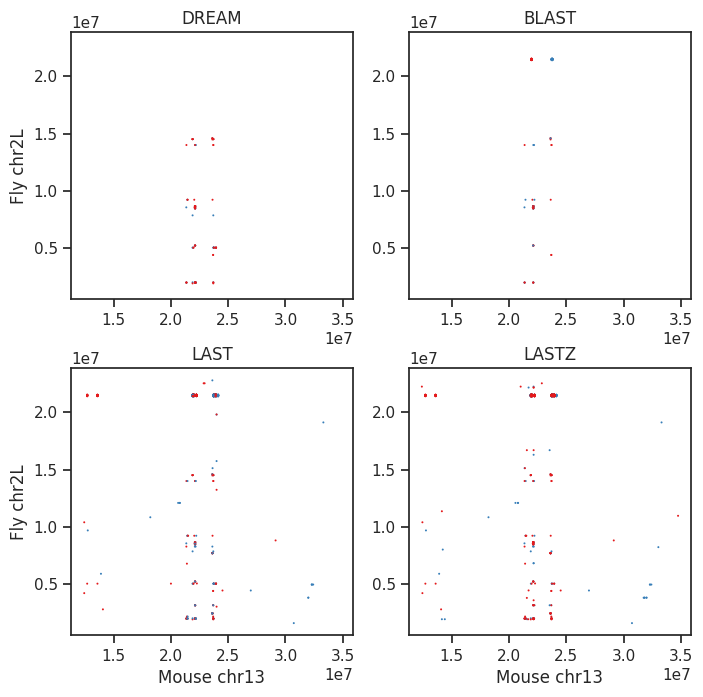

In [23]:
# BLAST and LAST max
dname = "NC_000079.7"
qname = "NT_033779.5"
dmin = 0.95e7
dmax = 3.5e7
dream = get_df(dream_all, dname, qname, dmin, dmax) 
blast = get_df(blast_all, dname, qname, dmin, dmax) 
last = get_df(last_all, dname, qname, dmin, dmax) 
lastz = get_df(lastz_all, dname, qname, dmin, dmax) 

plot_mouse_chr(dream, blast, last, lastz, full = False)

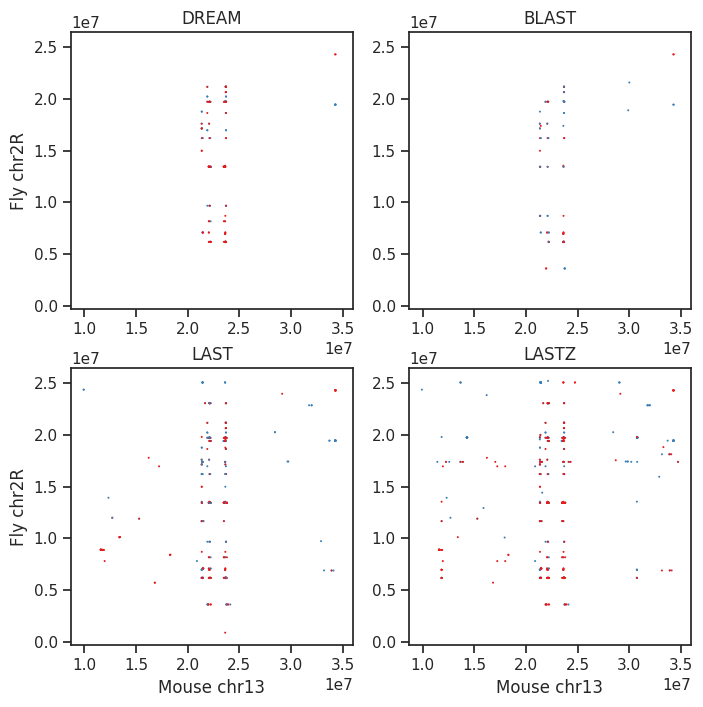

In [24]:
# DREAM max
dname = "NC_000079.7"
qname = "NT_033778.4"
dmin = 0.99e7
dmax = 3.5e7
dream = get_df(dream_all, dname, qname, dmin, dmax) 
blast = get_df(blast_all, dname, qname, dmin, dmax) 
last = get_df(last_all, dname, qname, dmin, dmax) 
lastz = get_df(lastz_all, dname, qname, dmin, dmax) 
            
plot_mouse_chr(dream, blast, last, lastz, full = False)

## Chromosome-wide homology

In [46]:
SMALLER_SIZE = 12
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 17

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALLER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALLER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [36]:
def plot_chr(dream, blast, last, postfix = ""):
    fig, ax = plt.subplots(1, 3, sharey = True, sharex = True)

    i = 0
    for df in [dream, blast, last]:
        for index, row in df.iterrows():
            if (row["strand"] == "+") or (row["strand"] == "plus"):
                ax[i].plot(np.array(row[["dbegin", "dend"]]), np.array(row[["qbegin", "qend"]]), '-', color = CB_color_cycle[0], label = "+")
            else:
                ax[i].plot(np.array(row[["dbegin", "dend"]]), np.array(row[["qbegin", "qend"]]), '-', color = CB_color_cycle[7], label = "-")
        ax[i].set_aspect('equal', 'box')
        i += 1
        

    # chr19
    #fig.set_figwidth(9)
    #fig.set_figheight(6)
    # chr1 
    fig.set_figwidth(11)
    fig.set_figheight(4)

    for i in range(3):
        ax[i].tick_params(bottom = True, labelbottom=True, left = True, labelleft=True)
    
    ax[0].set_title('DREAM')
    ax[1].set_title('BLAST')
    ax[2].set_title('LAST')
    
    #ax[2].legend(loc = "upper center")
    #fig.legend(handles, labels, loc='upper center')
    fig.subplots_adjust(bottom = 0.1, top = 0.87)
     
    human_chr = dream["dname"].iloc[0]
    # shared x label
    fig.text(0.5, 0.01, "Human " + human_chr, ha='center')
    
    ax[0].set_ylabel("Mouse chr" + mouse_dname_d.get(dream["qname"].iloc[0]))
    #bottom, top = ax[1].get_ylim()
    #ax[0].set_ylim(bottom, top)
    
    #fig.suptitle("Human and mouse synteny")
    fig.savefig(human_chr + postfix + '.svg', dpi = 200)
    fig.savefig(human_chr + postfix + '.png', dpi = 200)

In [38]:
def plot_dream_chr(dream):
    fig, ax = plt.subplots()

    i = 0
    for df in [dream]:
        for index, row in df.iterrows():
            if (row["strand"] == "+") or (row["strand"] == "plus"):
                ax.plot(np.array(row[["dbegin", "dend"]]), np.array(row[["qbegin", "qend"]]), '-', color = CB_color_cycle[0], label = "+")
            else:
                ax.plot(np.array(row[["dbegin", "dend"]]), np.array(row[["qbegin", "qend"]]), '-', color = CB_color_cycle[7], label = "-")
        ax.set_aspect('equal', 'box')
        i += 1
        

    # chr19
    #fig.set_figwidth(9)
    #fig.set_figheight(6)
    # chr1 
    fig.set_figwidth(6)
    #fig.set_figheight(5.3)

    ax.tick_params(bottom = True, labelbottom=True, left = True, labelleft=True)
    
    ax.set_title('DREAM')
    
    #ax[2].legend(loc = "upper center")
    #fig.legend(handles, labels, loc='upper center')
    fig.subplots_adjust(bottom = 0.15, top = 0.91)
     
    human_chr = dream["dname"].iloc[0]
    
    ax.set_xlabel("Human " + human_chr)
    ax.set_ylabel("Mouse chr" + mouse_dname_d.get(dream["qname"].iloc[0]))
    #bottom, top = ax[1].get_ylim()
    #ax[0].set_ylim(bottom, top)
    
    #fig.suptitle("Human and mouse synteny")
    #fig.savefig("dream_" + human_chr + '.svg', dpi = 200)
    fig.savefig("dream_" + human_chr + '.png', dpi = 200)

In [15]:
c = "chr1"

In [63]:
dream = read_stellar_output("human_dream_" + c + "_e6.gff")

if (c == "chr1"):
    dream = dream[(dream["dbegin"] > 1.5e8) & (dream["qbegin"] > 1e8)] 
elif (c == "chr19"):
    dream = dream[(dream["qbegin"] < 0.6e8)] 

dream = switch_reverse_coord(dream)
dream = fit_line_coord(dream)
dream.evalue = dream.evalue.str.removeprefix("eValue=")
dream = dream.astype({'evalue': 'float'})
dream = dream[dream["evalue"] <= 0]
dream.head()

,dname,dbegin,dend,percid,strand,len,qname,evalue,qbegin,qend,a,b
44,chr1,244853131,244853850,94.1095,+,719,NC_000067.7,0.0,178155613,178156327,0.993046,-6.499478e+07
65,chr1,244171550,244172256,94.0761,+,706,NC_000067.7,0.0,177400871,177401572,0.992918,-6.504142e+07
83,chr1,244053647,244055373,94.0057,+,1726,NC_000067.7,0.0,177274522,177276240,0.995365,-6.564794e+07
141,chr1,243415584,243416895,94.0015,+,1311,NC_000067.7,0.0,176773559,176774868,0.998474,-6.627068e+07
142,chr1,243415573,243416496,94.0604,+,923,NC_000067.7,0.0,176773552,176774469,0.993499,-6.505969e+07


In [64]:
#blast = read_blast_output("human_blast_" + c + "_mini.bed")

blast = read_blast_output("human_blast_" + c + "_e10_k28.bed")
#blast = read_blast_output("human_blast_" + c + "_not_eps.bed")
#blast = read_blast_output("human_blast_" + c + "_e10_k28.fp.bed")
#blast = read_stellar_output("human_blast_" + c + "_e10_k28.fn.gff")

if (c == "chr1"):
    blast = blast[(blast["dbegin"] > 1.5e8) & (blast["qbegin"] > 1e8)] 
elif (c == "chr19"):
    blast = blast[(blast["qbegin"] < 0.6e8)]

blast = blast[blast["evalue"] <= 0]

#index_list = list(range(0, len(blast)-1, 3))
#blast = blast[blast.index.isin(index_list)]
blast = fit_line_coord(blast)
blast.head()

,dname,dbegin,dend,percid,strand,evalue,qname,qbegin,qend,len,a,b
0,chr1,203800527,203795510,84.051,minus,0.0,NC_000067.7,133584325,133589256,5017,-0.982858,3.338914e+08
1,chr1,200409712,200406730,92.552,minus,0.0,NC_000067.7,136553017,136555990,2982,-0.996982,3.363579e+08
2,chr1,244053748,244056585,91.975,plus,0.0,NC_000067.7,177274615,177277456,2837,1.001410,-6.712323e+07
3,chr1,213998301,213996035,91.337,minus,0.0,NC_000067.7,189892677,189894949,2266,-1.002648,4.044576e+08
4,chr1,245685402,245688809,82.053,plus,0.0,NC_000067.7,178742324,178745743,3407,1.003522,-6.780842e+07


In [25]:
np.min(blast["evalue"])

np.float64(0.0)

In [28]:
len(blast)

14135

In [65]:
#last = read_blast_output("human_last_" + c + "_mini.bed")
last = read_blast_output("human_last_" + c + "_m10.bed")

#last = read_blast_output("human_last_" + c + "_not_eps.bed")
#last = read_blast_output("human_last_" + c + "_m10.fp.bed")

#last = read_stellar_output("human_last_" + c + "_m10.fn.gff")

if (c == "chr1"):
    last = last[(last["dbegin"] > 1.5e8) & (last["qbegin"] > 1e8)] 
elif (c == "chr19"):
    last = last[(last["qbegin"] < 0.6e8)]

last = last[last["evalue"] <= 0]
#index_list = list(range(0, len(last)-1, 6))
#last = last[last.index.isin(index_list)]
last = fit_line_coord(last)
last.head()

,dname,dbegin,dend,percid,strand,evalue,qname,qbegin,qend,len,a,b
0,chr1,203800551,203795461,82.51,minus,0.0,NC_000067.7,133584301,133589304,5090,-0.982908,3.339014e+08
1,chr1,200409807,200406730,91.17,minus,0.0,NC_000067.7,136552923,136555990,3077,-0.996750,3.363114e+08
7,chr1,204240431,204236640,78.69,minus,0.0,NC_000067.7,167652214,167656019,3791,-1.003693,3.726469e+08
8,chr1,204236640,204240431,78.69,plus,0.0,NC_000067.7,175672073,175675878,3791,1.003693,-2.931880e+07
11,chr1,204236640,204240431,78.67,plus,0.0,NC_000067.7,136992136,136995941,3791,1.003693,-6.799874e+07


In [40]:
len(last)

13275

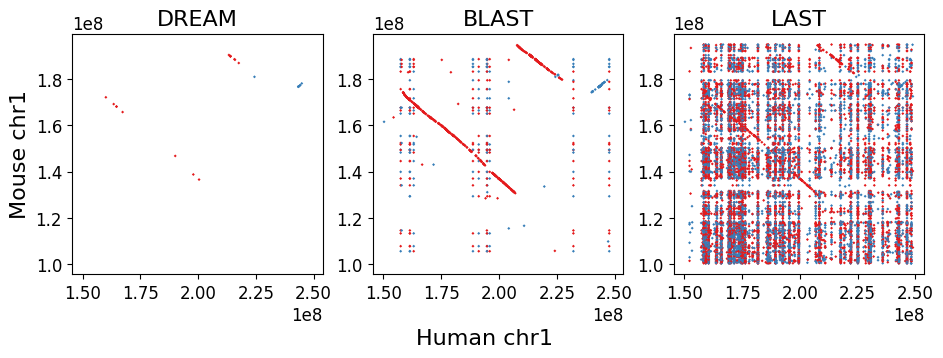

In [66]:
plot_chr(dream, blast, last, "_0")

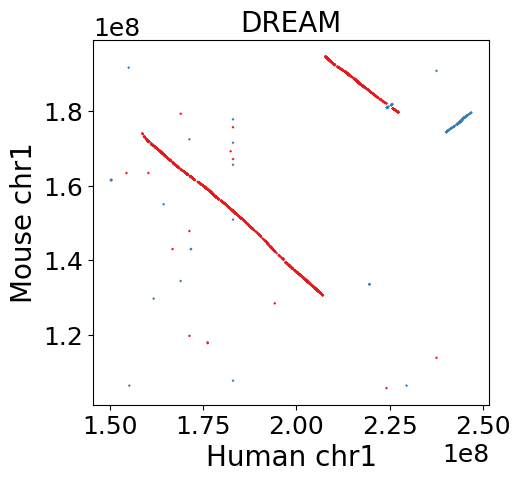

In [49]:
plot_dream_chr(dream)